In [23]:
import pandas as pd

In [24]:
df = pd.read_csv("C:/Users/Usuário/Downloads/canadian_immegration_data.csv")

In [25]:
df.set_index('Country', inplace=True)

In [26]:
anos = list(map(str, range(1980, 2014)))
brasil = df.loc['Brazil', anos]
argentina = df.loc['Argentina', anos]

In [27]:
brasil_dict = {'ano': brasil.index.tolist(), 'imigrantes': brasil.values.tolist()}
dados_brasil = pd.DataFrame(brasil_dict)

argentina_dict = {'ano': argentina.index.tolist(), 'imigrantes': argentina.values.tolist()}
dados_argentina = pd.DataFrame(brasil_dict)

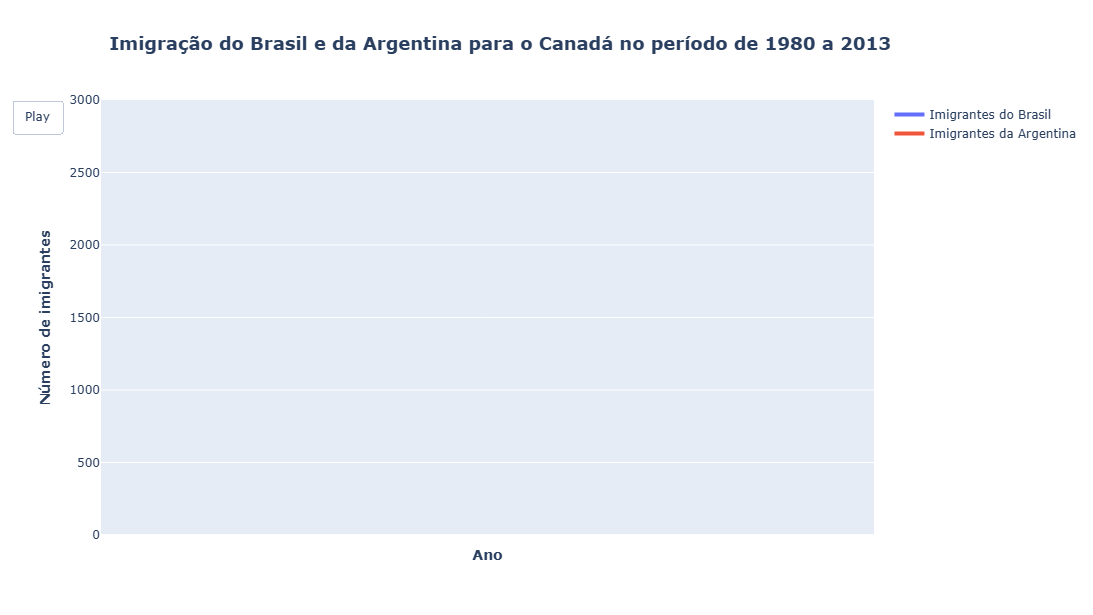

In [28]:
import plotly.graph_objs as go

# Criando uma figura
fig = go.Figure()

# Adicionando a linha com os dados do Brasil 
fig.add_trace(
    go.Scatter(x=[dados_brasil['ano'].iloc[0]], y=[dados_brasil['imigrantes'].iloc[0]], mode='lines', name='Imigrantes do Brasil', line=dict(width=4))
)

# Adicionando a linha com os dados da Argentina
fig.add_trace(
    go.Scatter(x=[dados_argentina['ano'].iloc[0]], y=[dados_argentina['imigrantes'].iloc[0]], mode='lines', name='Imigrantes da Argentina', line=dict(width=4))
)

# Definindo as configurações de layout
fig.update_layout(
    title=dict(
        text='<b>Imigração do Brasil e da Argentina para o Canadá no período de 1980 a 2013',
        x=0.1,

        font=dict(size=18)
    ),
    xaxis=dict(range=[1980, 2013], autorange=False, title='<b>Ano</b>'),
    yaxis=dict(range=[0, 3000], autorange=False, title='<b>Número de imigrantes</b>'),
    updatemenus=[dict(
        type='buttons',
        showactive=False,
        buttons=[dict(
            label='Play',
            method='animate',
            args=[None, {'frame': {'duration': 100, 'redraw': True}, 'fromcurrent': True}]
        )]
    )],
    width=1200, # largura da figura em pixels
    height=600 # altura da figura em pixels
)

# Definindo as configurações de animação
frames = []
for i in range(len(dados_brasil)):
    frame_data = [
        go.Scatter(x=dados_brasil['ano'].iloc[:i+1], y=dados_brasil['imigrantes'].iloc[:i+1]),
        go.Scatter(x=dados_argentina['ano'].iloc[:i+1], y=dados_argentina['imigrantes'].iloc[:i+1])
    ]
    frame = go.Frame(data=frame_data)
    frames.append(frame)
fig.frames = frames

# Mostrando a figura
fig.show()